In [1]:
from asmcmc.base.initialize import RandomLatticeInitializer, ColumnarLatticeInitializer, FrameInitializer
from asmcmc.base.metropolis import MetropolisCalculator
from asmcmc.base.potentials import GBQPotential, CACELLI_POTENTIAL
from asmcmc.utils.measurements import (
    TrajectoryAnalyzer, 
    RadialDistributionFunction, 
    OrientationalCorrelationFunction, 
    HeatCapacity, 
    NematicOrderParameter, 
    nematic_q_tensor,
    AverageEnthalpy
)

import pickle
import os
import glob

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from ase.db import connect
import ase.io

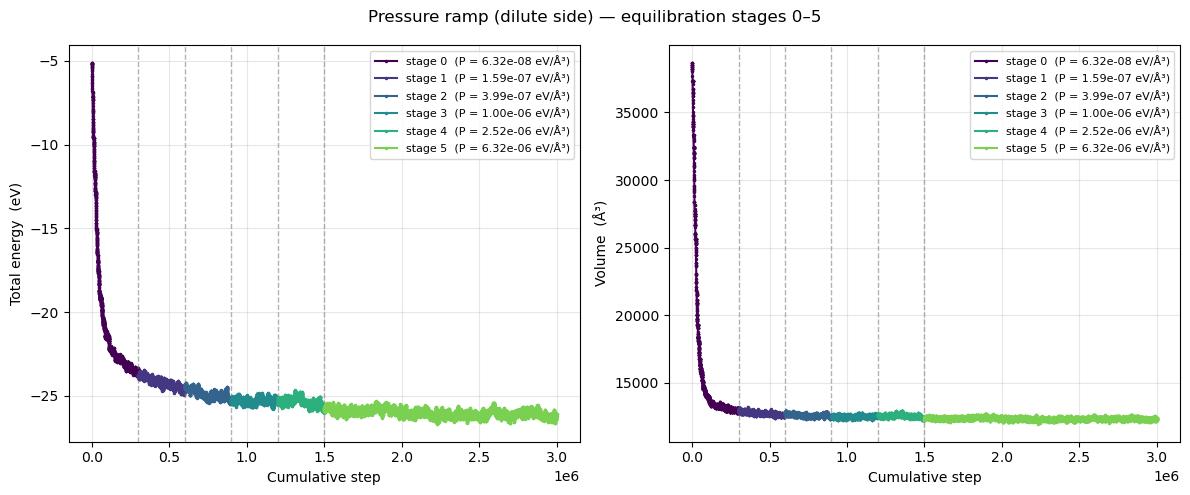

In [2]:
# Pressure-ramp overview: stack the first equilibration stages (dilute side)
# end-to-end on a shared step axis so the full densification path reads as one
# continuous trajectory. Each stage continues from the previous stage's final
# frame, so energy/volume flow across the stage boundaries (dashed grey lines).

DILUTE_DIR = "../results/validation/100.0_6.324209e-06/dilute"
STAGES = [0, 1, 2, 3, 4, 5]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0.0, 0.8, len(STAGES)))

offset = 0  # cumulative step count so the stages read as one continuous ramp
for stage, color in zip(STAGES, colors):
    (stage_dir,) = glob.glob(f"{DILUTE_DIR}/stage{stage:02d}_P*")
    pressure = float(stage_dir.split("_P")[1])

    steps, energy, vol = [], [], []
    with connect(f"{stage_dir}/equilibration.db") as db:
        for row in db.select():
            steps.append(row.step)
            energy.append(row.total_energy)
            vol.append(row.vol)

    order = np.argsort(steps)  # db.select() order isn't guaranteed monotonic
    steps = np.asarray(steps)[order] + offset
    energy = np.asarray(energy)[order]
    vol = np.asarray(vol)[order]

    label = f"stage {stage}  (P = {pressure:.2e} eV/Å³)"
    axs[0].plot(steps, energy, marker=".", ms=3, color=color, label=label)
    axs[1].plot(steps, vol, marker=".", ms=3, color=color, label=label)

    if stage != STAGES[-1]:  # mark the hand-off to the next stage
        for ax in axs:
            ax.axvline(steps[-1], color="gray", ls="--", lw=1, alpha=0.6)
    offset = steps[-1]

axs[0].set_ylabel("Total energy  (eV)")
axs[1].set_ylabel("Volume  (Å³)")
for ax in axs:
    ax.set_xlabel("Cumulative step")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Pressure ramp (dilute side) — equilibration stages 0–5")
fig.tight_layout()
plt.show()

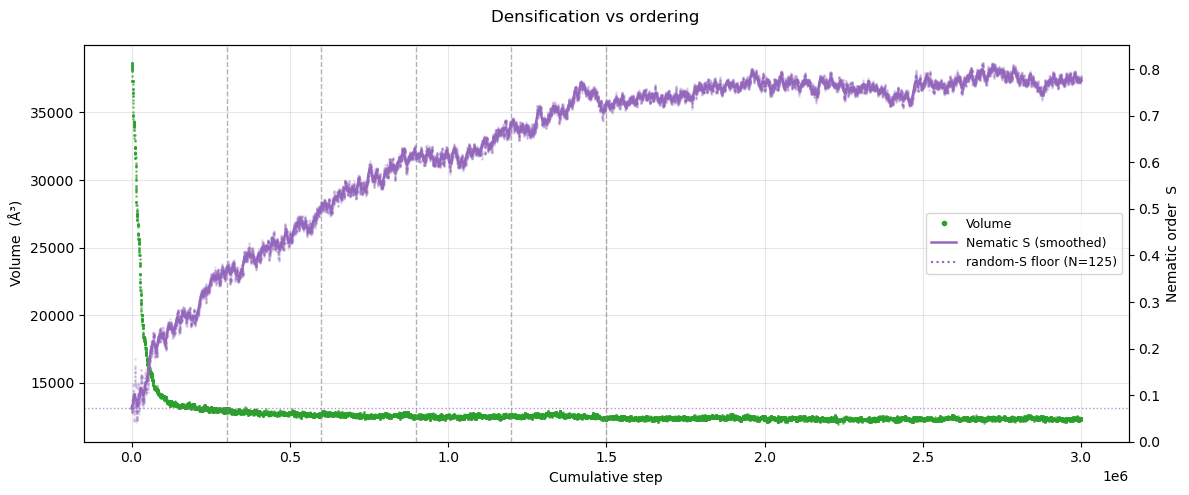

In [3]:
# Densification vs ordering: the test of whether the fast volume drop trapped a
# glass.  We want to see the nematic order parameter S rise even as the volume 
# begins to plateau

def _rolling(a, w=75):
    """Edge-padded boxcar mean, computed over the *concatenated* ramp so there
    are no spurious dips at the stage boundaries."""
    if len(a) < w:
        return a
    p = w // 2
    return np.convolve(np.pad(a, p, mode="edge"), np.ones(w) / w, mode="valid")[: len(a)]


all_steps, all_vol, all_s, boundaries = [], [], [], []
offset = 0
for stage in STAGES:
    (stage_dir,) = glob.glob(f"{DILUTE_DIR}/stage{stage:02d}_P*")
    steps, vol, s_vals = [], [], []
    with connect(f"{stage_dir}/equilibration.db") as db:
        for row in db.select():
            steps.append(row.step)
            vol.append(row.vol)
            q = nematic_q_tensor(np.asarray(row.data["or_vec"]))
            s_vals.append(np.linalg.eigvalsh(q)[-1])  # instantaneous S = largest eigval
    order = np.argsort(steps)
    all_steps.append(np.asarray(steps)[order] + offset)
    all_vol.append(np.asarray(vol)[order])
    all_s.append(np.asarray(s_vals)[order])
    if stage != STAGES[-1]:
        boundaries.append(all_steps[-1][-1])
    offset = all_steps[-1][-1]

steps = np.concatenate(all_steps)
vol = np.concatenate(all_vol)
s_vals = np.concatenate(all_s)

fig, ax = plt.subplots(figsize=(12, 5))
ax_s = ax.twinx()

ax.plot(steps, vol, ".", ms=2, color="tab:green", alpha=0.5)
ax_s.plot(steps, s_vals, ".", ms=2, color="tab:purple", alpha=0.15)
ax_s.plot(steps, _rolling(s_vals), "-", color="tab:purple", lw=1.8)

for b in boundaries:  # stage hand-offs
    ax.axvline(b, color="gray", ls="--", lw=1, alpha=0.6)
# random-orientation floor of the max-eigenvalue estimator at N=125
ax_s.axhline(0.073, color="tab:purple", ls=":", lw=1, alpha=0.7)

ax.set_xlabel("Cumulative step")
#ax.set_ylabel("Volume  (Å³)", color="tab:green")
#ax_s.set_ylabel("Nematic order  S", color="tab:purple")
#ax.tick_params(axis="y", labelcolor="tab:green")
#ax_s.tick_params(axis="y", labelcolor="tab:purple")
ax.set_ylabel("Volume  (Å³)")
ax_s.set_ylabel("Nematic order  S")
ax_s.set_ylim(0, None)
ax.grid(True, alpha=0.3)

ax.legend(
    handles=[
        Line2D([0], [0], color="tab:green", marker=".", ls="", label="Volume"),
        Line2D([0], [0], color="tab:purple", lw=1.8, label="Nematic S (smoothed)"),
        Line2D([0], [0], color="tab:purple", ls=":", label="random-S floor (N=125)"),
    ],
    loc="center right",
    fontsize=9,
)

fig.suptitle("Densification vs ordering")
fig.tight_layout()
plt.show()

In [4]:
eq_traj = []

with connect("../results/validation/100.0_6.324209e-06/dense/equilibration.db") as db:
    for row in db.select():
        atoms = row.toatoms()
        atoms.new_array("c_q", np.asarray(row.data["c_q"]))
        atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
        atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for a in atoms]))
        eq_traj.append(atoms)

ase.io.write("../results/validation/100.0_6.324209e-06/dense/equilibration.xyz", eq_traj, format="extxyz")

KeyboardInterrupt: 

In [12]:
sim_traj = []

with connect("../results/validation/100.0_6.324209e-06/dense/simulation.db") as db:
    for row in db.select():
        atoms = row.toatoms()
        atoms.new_array("c_q", np.asarray(row.data["c_q"]))
        atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
        atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for a in atoms]))
        sim_traj.append(atoms)

ase.io.write("../results/validation/100.0_6.324209e-06/dense/simulation.xyz", sim_traj, format="extxyz")

In [5]:
import json

RUN_DIR = "../results/validation/100.0_6.324209e-06/dense"

# Pull the state point straight from the run's write-once config so the
# measurements stay consistent with how the trajectory was generated.
with open(f"{RUN_DIR}/run_config.json") as f:
    config = json.load(f)

temp = config["temp"]
pressure = config["pressure"]
n_particles = config["init"]["init_n_particles"]

# r_max stays below half the (NPT-fluctuating) box: the RDF/OCF only fill bins
# inside each frame's L/2, and the smallest L/2 over this run is ~11.5 A.
R_MAX = 11.5
NUM_BINS = 115

analyzer = TrajectoryAnalyzer(f"{RUN_DIR}/simulation.db")
analyzer.add_measurement("rdf", RadialDistributionFunction(R_MAX, NUM_BINS))
analyzer.add_measurement("ocf", OrientationalCorrelationFunction(R_MAX, NUM_BINS))
analyzer.add_measurement("nematic", NematicOrderParameter())
analyzer.add_measurement("enthalpy", AverageEnthalpy(pressure))
analyzer.add_measurement("heat_capacity", HeatCapacity(temp, n_particles, pressure=pressure))

In [6]:
# Run every measurement over the trajectory and cache the results to a pickle.
# Re-running this cell loads the cached results instead of re-scanning the
# 12k-frame db; delete the pickle to force a recompute.
results_path = f"{RUN_DIR}/analysis_results.pkl"

if os.path.exists(results_path):
    with open(results_path, "rb") as f:
        results = pickle.load(f)
    print(f"Loaded cached results from {results_path}")
else:
    results = analyzer.run_analysis()
    with open(results_path, "wb") as f:
        pickle.dump(results, f)
    print(f"Saved results to {results_path}")

results

Analyzing Trajectory:   0%|          | 0/16000 [00:00<?, ?it/s]

Saved results to ../results/validation/100.0_6.324209e-06/dense/analysis_results.pkl


{'rdf': {'r': array([ 0.05,  0.15,  0.25,  0.35,  0.45,  0.55,  0.65,  0.75,  0.85,
          0.95,  1.05,  1.15,  1.25,  1.35,  1.45,  1.55,  1.65,  1.75,
          1.85,  1.95,  2.05,  2.15,  2.25,  2.35,  2.45,  2.55,  2.65,
          2.75,  2.85,  2.95,  3.05,  3.15,  3.25,  3.35,  3.45,  3.55,
          3.65,  3.75,  3.85,  3.95,  4.05,  4.15,  4.25,  4.35,  4.45,
          4.55,  4.65,  4.75,  4.85,  4.95,  5.05,  5.15,  5.25,  5.35,
          5.45,  5.55,  5.65,  5.75,  5.85,  5.95,  6.05,  6.15,  6.25,
          6.35,  6.45,  6.55,  6.65,  6.75,  6.85,  6.95,  7.05,  7.15,
          7.25,  7.35,  7.45,  7.55,  7.65,  7.75,  7.85,  7.95,  8.05,
          8.15,  8.25,  8.35,  8.45,  8.55,  8.65,  8.75,  8.85,  8.95,
          9.05,  9.15,  9.25,  9.35,  9.45,  9.55,  9.65,  9.75,  9.85,
          9.95, 10.05, 10.15, 10.25, 10.35, 10.45, 10.55, 10.65, 10.75,
         10.85, 10.95, 11.05, 11.15, 11.25, 11.35, 11.45]),
  'g_r': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 

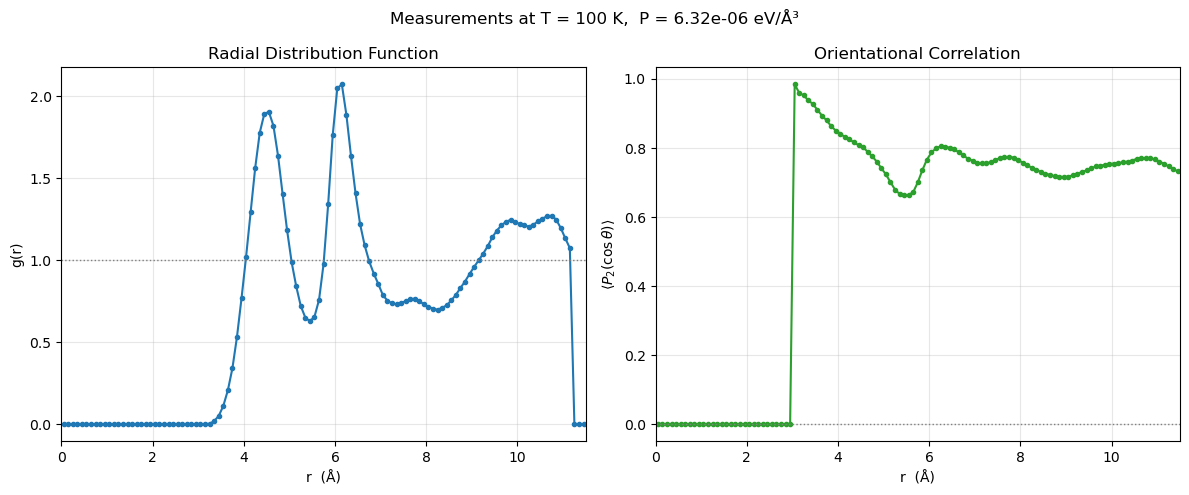

Nematic order:  S = 0.864 ± 0.009  (S_lab = 0.864)
Director:       [-0.068 -0.049 -0.997]
Enthalpy:       H = -27.114 ± 0.219 eV   (H/N = -0.2169 eV)
Heat capacity:  C_p = 7.031e-04 eV/K/particle  (8.16 k_B/particle)


In [7]:
from asmcmc.utils.measurements import BOLTZCONST

rdf = results["rdf"]
ocf = results["ocf"]
nematic = results["nematic"]
H_mean, H_std = results["enthalpy"]
cp = results["heat_capacity"]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Radial distribution function g(r): positional order
axs[0].plot(rdf["r"], rdf["g_r"], marker=".")
axs[0].axhline(1.0, color="gray", ls=":", lw=1)
axs[0].set_xlabel("r  (Å)")
axs[0].set_ylabel("g(r)")
axs[0].set_title("Radial Distribution Function")

# Orientational correlation <P2(cos θ)>(r): neighbour alignment vs separation
axs[1].plot(ocf["r"], ocf["s2_r"], marker=".", color="tab:green")
axs[1].axhline(0.0, color="gray", ls=":", lw=1)
axs[1].set_xlabel("r  (Å)")
axs[1].set_ylabel(r"$\langle P_2(\cos\theta)\rangle$")
axs[1].set_title("Orientational Correlation")

for ax in axs:
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, R_MAX)

fig.suptitle(f"Measurements at T = {temp:g} K,  P = {pressure:.3g} eV/Å³")
fig.tight_layout()

# fig.savefig(f"{RUN_DIR}/measurements.png", dpi=150)

plt.show()

# Scalar observables
print(f"Nematic order:  S = {nematic['S']:.3f} ± {nematic['S_std']:.3f}  (S_lab = {nematic['S_lab']:.3f})")
print(f"Director:       {np.array2string(nematic['director'], precision=3)}")
print(f"Enthalpy:       H = {H_mean:.3f} ± {H_std:.3f} eV   (H/N = {H_mean / n_particles:.4f} eV)")
print(f"Heat capacity:  C_p = {cp:.3e} eV/K/particle  ({cp / BOLTZCONST:.2f} k_B/particle)")